<a href="https://colab.research.google.com/github/LukaUshveridze99/Data-Analysis/blob/main/Cyclistic_Bike_Share.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study 1: How Does a Bike-Share Navigate Speedy Success?
### Google Data Analytics Professional Certificate Capstone Project
**Author:** Luka Ushveridze  
**Date:** June 2026  
**Language:** Python (Pandas, Matplotlib, Seaborn)

---

## 1. Ask Phase
### Business Objective
The goal of this analysis is to identify how annual members and casual riders use Cyclistic bikes differently. These insights will help the marketing director design data-driven strategies to convert casual riders into high-value annual members.

---

## 2. Prepare Phase
### Data Sourcing & Environment Setup
We are utilizing the historical trip data from the last 12 consecutive months. In this section, we set up our environment by importing necessary libraries (`pandas`, `os`, `matplotlib`, `seaborn`) and dynamically loading and concatenating the 12 separate monthly CSV files into a unified master DataFrame.

In [ ]:
import os
import pandas as pd

# Colab's default file directory is /content
folder_path = "/content"

# Find all bike CSV files (filtering out default Colab sample data)
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv") and "sample_data" not in f]

# Read and combine
df_list = []
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    print(f"Reading: {file}")
    df = pd.read_csv(file_path)
    df_list.append(df)

combined_df = pd.concat(df_list, ignore_index=True)
print(f"\n--- Success! Combined dataset contains {combined_df.shape[0]:,} rows. ---")

# Initial Data Inspection
combined_df.info()
combined_df.head()

Reading: 202510-divvy-tripdata.csv
Reading: 202507-divvy-tripdata.csv
Reading: 202509-divvy-tripdata.csv
Reading: 202512-divvy-tripdata.csv
Reading: 202504-divvy-tripdata.csv
Reading: 202508-divvy-tripdata.csv
Reading: 202503-divvy-tripdata.csv
Reading: 202511-divvy-tripdata.csv
Reading: 202501-divvy-tripdata.csv
Reading: 202506-divvy-tripdata.csv
Reading: 202505-divvy-tripdata.csv
Reading: 202502-divvy-tripdata.csv

--- Success! Combined dataset contains 5,552,994 rows. ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5552994 entries, 0 to 5552993
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_la

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,AAED255E1310E516,classic_bike,2025-10-27 08:19:53.208,2025-10-27 08:25:53.481,Wells St & Polk St,CHI00606,Franklin St & Washington St,CHI02074,41.872732,-87.633516,41.883180,-87.635110,member
1,F90C86BF3BB85040,classic_bike,2025-10-14 07:42:55.465,2025-10-14 08:04:08.663,Racine Ave & Wrightwood Ave,CHI00506,McClurg Ct & Ohio St,CHI00330,41.928887,-87.658971,41.892592,-87.617289,member
2,90429D9729A3EE8E,classic_bike,2025-10-12 08:18:23.613,2025-10-12 08:28:38.983,Clinton St & 18th St,CHI00235,Desplaines St & Jackson Blvd,CHI00518,41.857950,-87.640826,41.878119,-87.643948,casual
3,C8433F9B78A1E63D,electric_bike,2025-10-14 07:45:56.471,2025-10-14 08:07:24.447,Pine Grove Ave & Irving Park Rd,CHI00482,Wells St & Huron St,CHI00294,41.954398,-87.647997,41.894795,-87.634374,member
4,62F3C413C442C154,electric_bike,2025-10-19 10:08:45.138,2025-10-19 10:12:34.771,Pine Grove Ave & Irving Park Rd,CHI00482,Sheridan Rd & Montrose Ave,CHI00290,41.954365,-87.647929,41.961670,-87.654640,member


---

## 3. Process Phase
### Data Diagnostics, Cleaning & Transformation
To ensure data integrity, we perform several data-cleaning tasks:
1. Check user classification categories for consistency.
2. Quantify missing values and drop unusable rows missing coordinate metrics.
3. Check for duplicates.
4. Convert date string columns into datetime formats to handle math operations.
5. Create derived attributes (`ride_length_mins`, `day_of_week`, `month`) to track trip characteristics.
6. Filter out systemic anomalies, test entries, and data glitches (trips lasting less than 1 minute or with negative durations).

---


In [ ]:
# Initial Integrity Diagnostics
print("Checking unique user categories:")
print(combined_df['member_casual'].value_counts())

print("\nMissing values per column:")
print(combined_df.isnull().sum())

print(f"\nDuplicate rows: {combined_df.duplicated().sum()}")

# Data Transformation & Filtering Pipeline
print("\nConverting date columns to datetime...")
combined_df['started_at'] = pd.to_datetime(combined_df['started_at'])
combined_df['ended_at'] = pd.to_datetime(combined_df['ended_at'])

# Calculate ride lengths in minutes
combined_df['ride_length_mins'] = (combined_df['ended_at'] - combined_df['started_at']).dt.total_seconds() / 60

# Extract time attributes for analysis
combined_df['day_of_week'] = combined_df['started_at'].dt.day_name()
combined_df['month'] = combined_df['started_at'].dt.strftime('%B')

# Filter: Keep only trips >= 1 minute and positive durations
print("Filtering out bad data and missing coordinates...")
cleaned_df = combined_df[combined_df['ride_length_mins'] >= 1].copy()
cleaned_df = cleaned_df.dropna(subset=['end_lat', 'end_lng'])

# Data Loss Summary
rows_removed = combined_df.shape[0] - cleaned_df.shape[0]
print(f"\n--- Cleaning Complete ---")
print(f"Rows removed (glitches/trips < 1 min): {rows_removed:,}")
print(f"Remaining clean rows for analysis: {cleaned_df.shape[0]:,}")

Checking unique user categories:
member_casual
member    3553497
casual    1999497
Name: count, dtype: int64

Missing values per column:
ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1184673
start_station_id      1184673
end_station_name      1243305
end_station_id        1243305
start_lat                   0
start_lng                   0
end_lat                  5535
end_lng                  5535
member_casual               0
dtype: int64

Duplicate rows: 0

Converting date columns to datetime...
Filtering out bad data and missing coordinates...

--- Cleaning Complete ---
Rows removed (glitches/trips < 1 min): 152,936
Remaining clean rows for analysis: 5,400,058


---

## 4. Analyze Phase
### Data Aggregation & Trend Extraction
With a verified, cleaned dataset of over 5.4 million records, we run descriptive statistics to uncover behavioral variations. We isolate distributions, trip volumes, and averages grouped by user type to identify clear variances between casual users and long-term members across months, days, and product preferences.

In [ ]:
# Comprehensive statistical summary of ride lengths
print("Overall Ride Length Summary:")
print(cleaned_df['ride_length_mins'].describe())

# Behavioral breakdown by user type
print("\nRide Length Distribution: Casual vs Member:")
print(cleaned_df.groupby('member_casual')['ride_length_mins'].describe().T)

# Aggregation 1: Day of the Week Volume
day_counts = cleaned_df.groupby(['day_of_week', 'member_casual']).size().unstack()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = day_counts.reindex(days_order)
print("\nRide Volume by Day of the Week:")
print(day_counts)

# Aggregation 2: Monthly Seasonality Volume
month_counts = cleaned_df.groupby(['month', 'member_casual']).size().unstack()
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
month_counts = month_counts.reindex(months_order)
print("\nRide Volume by Month:")
print(month_counts)

# Aggregation 3: Bike Type Preference
bike_preferences = cleaned_df.groupby(['rideable_type', 'member_casual']).size().unstack()
print("\nBike Preference Breakdown:")
print(bike_preferences)

Overall Ride Length Summary:
count    5.400058e+06
mean     1.496125e+01
std      3.008823e+01
min      1.000000e+00
25%      5.676183e+00
50%      9.676767e+00
75%      1.683207e+01
max      1.499968e+03
Name: ride_length_mins, dtype: float64

Ride Length Distribution: Casual vs Member:
member_casual        casual        member
count          1.915835e+06  3.484223e+06
mean           1.998130e+01  1.220092e+01
std            4.110536e+01  2.127308e+01
min            1.000017e+00  1.000000e+00
25%            6.823467e+00  5.210633e+00
50%            1.189353e+01  8.738083e+00
75%            2.168618e+01  1.467230e+01
max            1.499968e+03  1.499966e+03

Ride Volume by Day of the Week:
member_casual  casual  member
day_of_week                  
Monday         219239  493326
Tuesday        216936  552541
Wednesday      212748  540214
Thursday       247896  565181
Friday         306472  518548
Saturday       395578  439875
Sunday         316966  374538

Ride Volume by Month:
member_

---

## 5. Share Phase
### Data Visualizations
To translate numeric insights into executive-level narratives, we construct targeted visualizations:
* **Weekly Patterns:** A grouped bar chart highlighting workweek vs. weekend utilization profiles.
* **Macro-Seasonality:** A line chart displaying user elasticity and operational drops based on seasonal shifts.
* **Product Preferences:** A stacked chart isolating electric vs. classic bicycle volume dynamics.

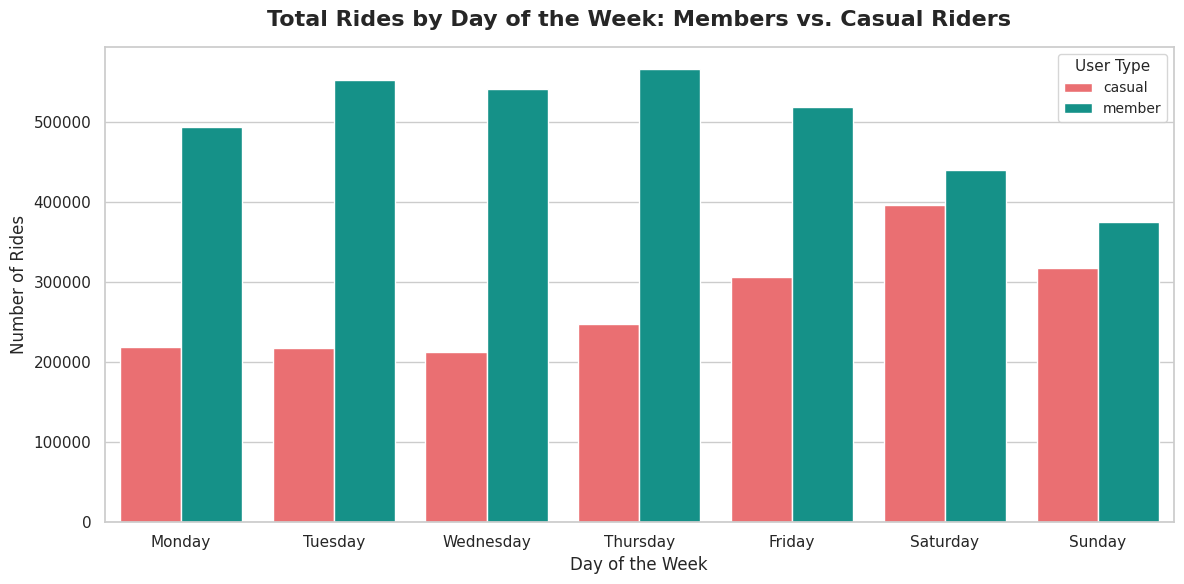

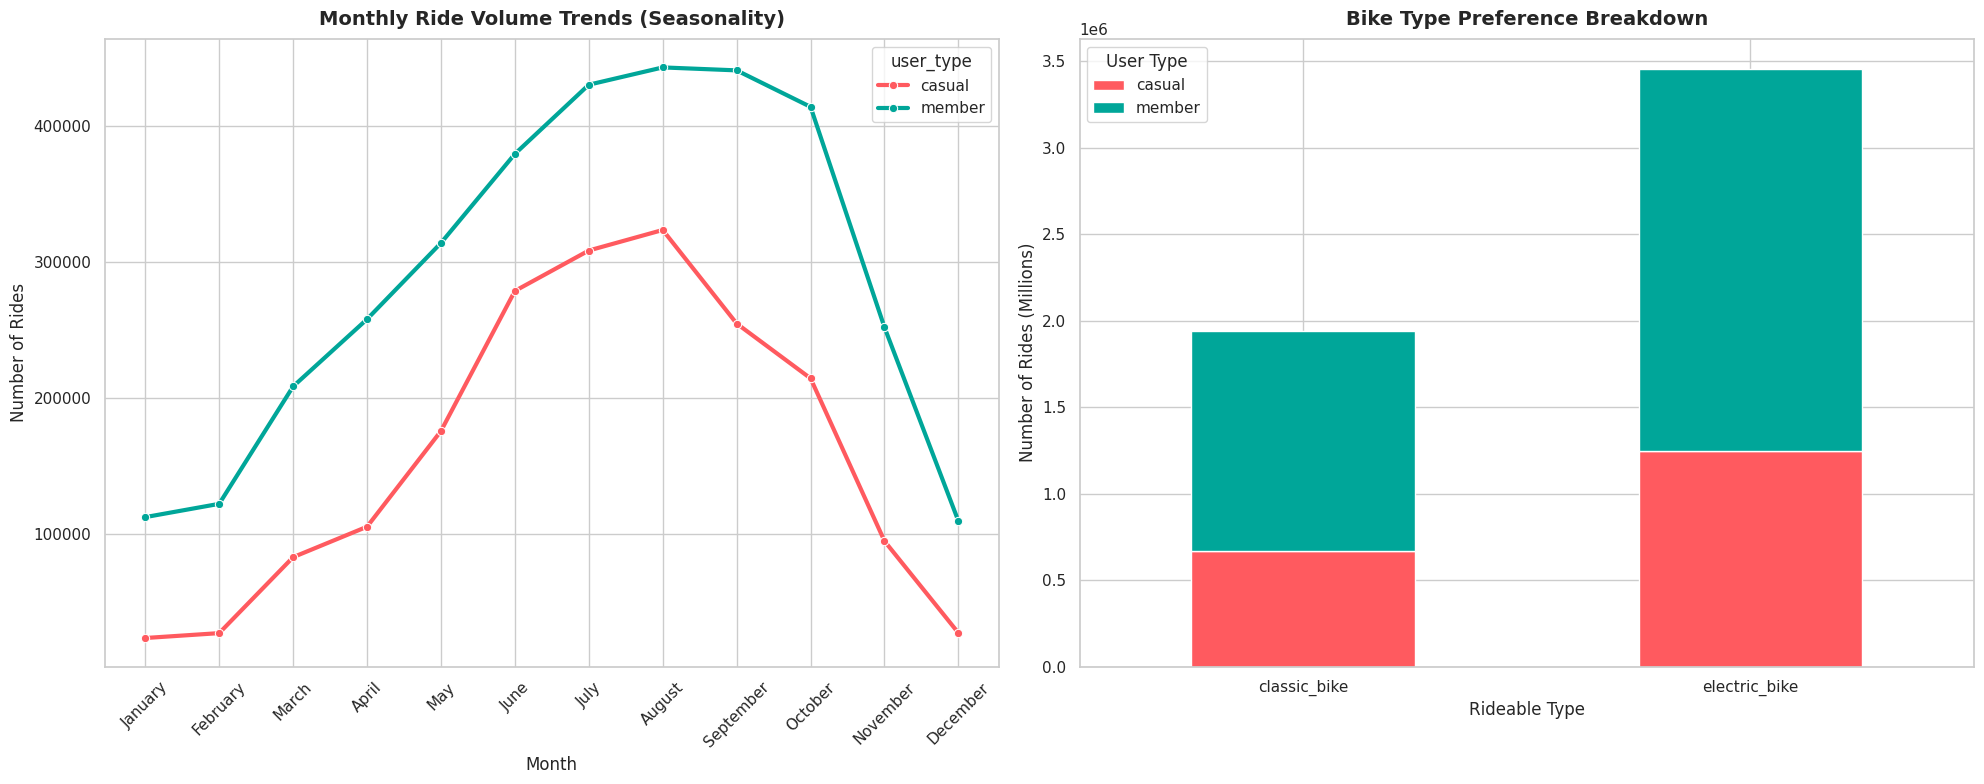

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- VISUALIZATION 1: Day of the Week Analysis ---
plot_data = day_counts.reset_index().melt(id_vars='day_of_week', value_vars=['casual', 'member'],
                                          var_name='user_type', value_name='total_rides')

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.barplot(x='day_of_week', y='total_rides', hue='user_type', data=plot_data, palette=['#FF5A5F', '#00A699'])

plt.title('Total Rides by Day of the Week: Members vs. Casual Riders', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.legend(title='User Type', title_fontsize='11', fontsize='10')
plt.tight_layout()
plt.show()


# --- VISUALIZATIONS 2 & 3: Seasonality & Bike Preferences ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Monthly Seasonality Line Chart
plot_months = month_counts.reset_index().melt(id_vars='month', value_vars=['casual', 'member'],
                                             var_name='user_type', value_name='rides')

sns.lineplot(ax=axes[0], data=plot_months, x='month', y='rides', hue='user_type',
             marker='o', linewidth=3, palette=['#FF5A5F', '#00A699'])
axes[0].set_title('Monthly Ride Volume Trends (Seasonality)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Number of Rides', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Bike Type Preferences Stacked Bar Chart
bike_preferences.plot(kind='bar', stacked=True, ax=axes[1], color=['#FF5A5F', '#00A699'], edgecolor='white')
axes[1].set_title('Bike Type Preference Breakdown', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Rideable Type', fontsize=12)
axes[1].set_ylabel('Number of Rides (Millions)', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='User Type')

plt.tight_layout()
plt.show()

---

## 6. Act Phase
### Data-Driven Strategic Recommendations
Based on the empirical evidence surfaced throughout our analytics pipeline, we propose three tactical marketing directions to drive annual conversions:

1. **The "Weekend Warrior" Membership Tier:** Capitalize on the distinct casual weekend surge by building a subscription plan specifically optimized for Friday–Sunday leisure usage.
2. **Targeting the Long-Trip Penalty Surcharge:** Deploy push notifications or physical station marketing emphasizing the cost savings of an annual subscription for trips exceeding the typical 12-minute member average.
3. **High-Value Seasonal Campaigns:** Focus key digital acquisition campaigns strictly between May and September within high-density recreational zones where casual trip volume natively explodes.